In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('Fish.csv')

In [4]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


Simple linear Regression

In [5]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

<Axes: >

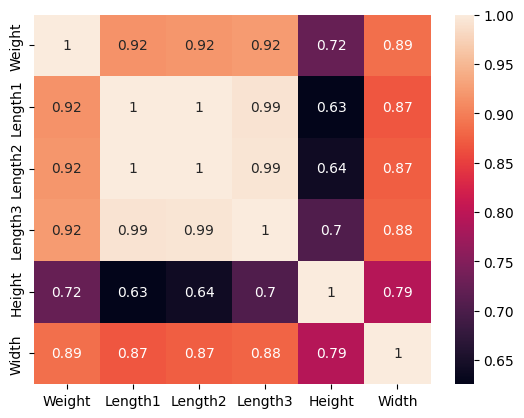

In [8]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Length1', ylabel='Weight'>

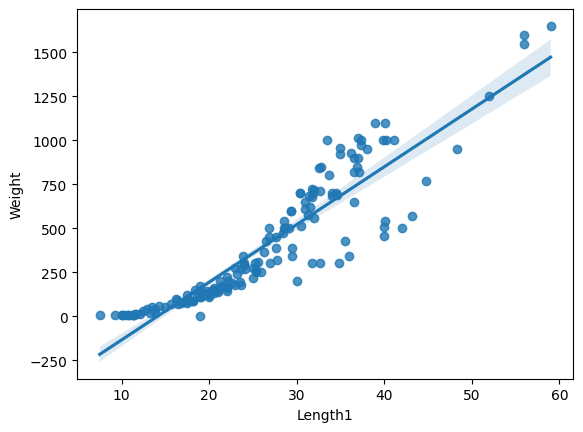

In [9]:
sns.regplot(data=df,x='Length1',y='Weight')

for predicting weight from length1

In [19]:
x = df[['Length1']]
y = df[['Weight']]

## split in two part train and test

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [22]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(127, 1)
(32, 1)
(127, 1)
(32, 1)


## Build a model 

In [24]:
from sklearn.linear_model import LinearRegression

In [27]:
model=LinearRegression()

In [28]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
model.coef_

array([[32.44308998]])

In [30]:
model.intercept_

array([-464.13411601])

In [32]:
y_pred=model.predict(X_test)

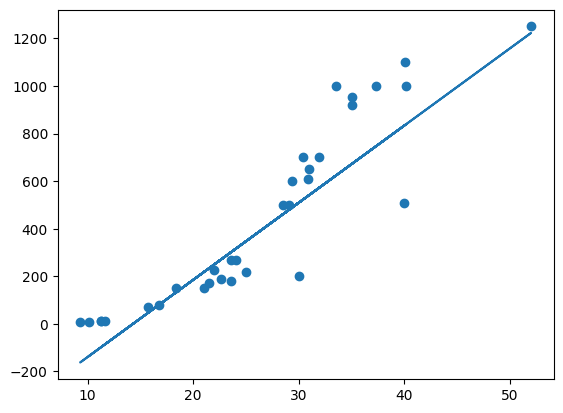

In [33]:
plt.plot(X_test,y_pred)
plt.scatter(X_test,y_test)
plt.show()

In [35]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [37]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

129.36788419512138
26796.684740821383
0.8116084146869397


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import pandas as pd
import numpy as np

In [42]:
df=pd.read_csv('Fish.csv')
x=df.drop(['Species','Weight'],axis=1)
y=df[['Weight']]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

109.0632714203943
21303.013279012117
0.8679594534557271


In [46]:
df=pd.read_csv('Fish.csv')
x=df.drop(['Species','Weight'],axis=1)
y=df[['Weight']]
test=[0.75,0.8,0.85,0.9,0.95]
mse = []
r2 = []
for i in test :
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=40)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))

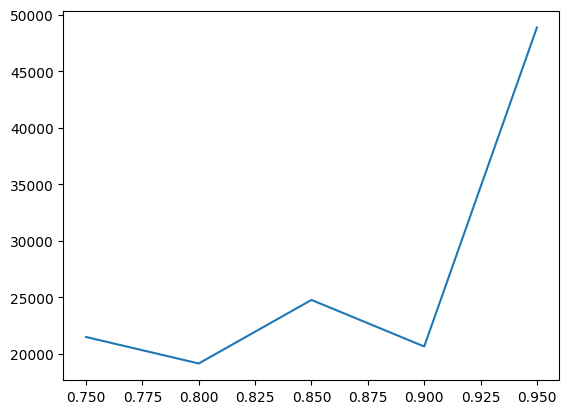

In [47]:
plt.plot(test,mse)

In [48]:
df = pd.read_csv('Ice_cream selling data.csv')
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [49]:
x=df[['Temperature (°C)']]
y=df[['Ice Cream Sales (units)']]

In [50]:
x_train,x_test,y_train,y_test=train_test_split(x,y,
                                              test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

14.28681469049703
288.6596992061606
-0.4122082415321706


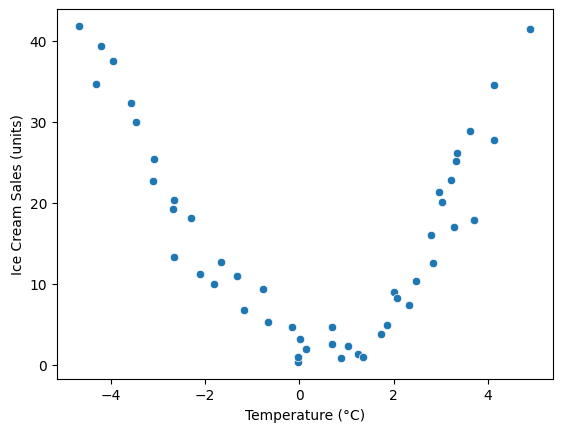

In [55]:
sns.scatterplot(data=df,x='Temperature (°C)',y='Ice Cream Sales (units)')
plt.show()